In [ ]:
import umap 
import numpy as np
import pandas as pd
from adjustText import adjust_text
import scipy.stats as stats
import matplotlib.pyplot as plt

# UMAP of bacterial orders
# Ran on qc3 (you need to change file paths before running)

/Users/madeline/Desktop/lab2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Scale sizes (size of umap dots) function -> Mean order relative abundance to 
# Min max normalization formula
def scale_sizes(abundances_array, min_s = 30, max_s = 360, max_abundance = 0.3):
    abundances_array = np.asarray(abundances_array, dtype=float)
    scaling_frac = np.sqrt(abundances_array / max_abundance)
    size = min_s + scaling_frac * (max_s - min_s)
    return size

# Clean label for order names -> split the o__ prefix and the pipe character . You always want the last thing because that's the order name. [-1]
def clean_label(taxa_name):
    # Split on pipe
    split_pipe = taxa_name.split("|")[-1]
    #  Split at the __ of the o prefix
    split_o = split_pipe.split("__")[-1]
    return split_o

In [4]:
# Read in da data

qc3_df = pd.read_csv('qc3_duplicates_removed_prevalence_1pct.csv', 
                     index_col=0)

# Sanity check
print("QC3 dataset shape:", qc3_df.shape)

print("QC3 dataset head:")
display(qc3_df.head())

# Seperate metadata and make age col
ages = qc3_df["age"]
metadata = qc3_df[["age", "weight"]]
features = qc3_df.drop(columns=["age", "weight"])

# Sanity checkies
print("Metadata shape:", metadata.shape)
print("Features shape:", features.shape)

# Metadata head
print("Metadata head:")
display(metadata.head())

# Features head
print("Features head:")
display(features.head())

QC3 dataset shape: (1125, 377)
QC3 dataset head:


,age,weight,k__Bacteria,k__Bacteria|p__Actinobacteria,k__Bacteria|p__Actinobacteria|c__Actinomycetia,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bowdenii,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bowdenii|t__SGB33755,...,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mesomycoplasma,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mesomycoplasma|s__Mesomycoplasma_molare,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mesomycoplasma|s__Mesomycoplasma_molare|t__SGB28759,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_canis,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_canis|t__SGB5941,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_edwardii,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_edwardii|t__SGB28786,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_maculosa,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_maculosa|t__SGB28743
sample_id,,,,,,,,,,,,,,,,,,,,,
DW31240510808865,5.0,170.0,1,0.028636,0.028636,0.015828,0.015828,0.008205,0.002611,0.002611,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
DW31240510802107,1.0,166.0,1,0.004132,0.004132,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
DW31240510806513,6.0,166.0,1,0.015808,0.015808,0.007428,0.007428,0.000913,0.000000,0.000000,...,0.0,0.0,0.0,0.002536,0.002536,0.002536,0.0,0.0,0.0,0.0
DW31240510806340,4.0,165.0,1,0.019847,0.019847,0.003984,0.003984,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000691,0.000691,0.000691,0.0,0.0,0.0,0.0
DW31240663106415,3.0,165.0,1,0.009659,0.009659,0.009034,0.009034,0.005672,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0


Metadata shape: (1125, 2)
Features shape: (1125, 375)
Metadata head:


,age,weight
sample_id,,
DW31240510808865,5.0,170.0
DW31240510802107,1.0,166.0
DW31240510806513,6.0,166.0
DW31240510806340,4.0,165.0
DW31240663106415,3.0,165.0


Features head:


,k__Bacteria,k__Bacteria|p__Actinobacteria,k__Bacteria|p__Actinobacteria|c__Actinomycetia,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bowdenii,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bowdenii|t__SGB33755,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bowdenii|t__SGB86824,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_respiraculi,...,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mesomycoplasma,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mesomycoplasma|s__Mesomycoplasma_molare,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mesomycoplasma|s__Mesomycoplasma_molare|t__SGB28759,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_canis,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_canis|t__SGB5941,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_edwardii,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_edwardii|t__SGB28786,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_maculosa,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_maculosa|t__SGB28743
sample_id,,,,,,,,,,,,,,,,,,,,,
DW31240510808865,1,0.028636,0.028636,0.015828,0.015828,0.008205,0.002611,0.002611,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
DW31240510802107,1,0.004132,0.004132,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
DW31240510806513,1,0.015808,0.015808,0.007428,0.007428,0.000913,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.002536,0.002536,0.002536,0.0,0.0,0.0,0.0
DW31240510806340,1,0.019847,0.019847,0.003984,0.003984,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000691,0.000691,0.000691,0.0,0.0,0.0,0.0
DW31240663106415,1,0.009659,0.009659,0.009034,0.009034,0.005672,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0


In [5]:
# Select col names with order features only
order_features_only = [
    col for col in features.columns
    if "|o__" in col and "|f__" not in col
    and "|o__OFGB" not in col
]

# -> Create a new dataframe with only order level features + abundances -> use da list
order_features_only_df = features[order_features_only]

# After, check if everything sums to 1 - now that OGBS are gone -> check after renormalizing everything sums to 1
print("Sum of order level features per row:")
print(order_features_only_df.sum(axis=1).describe())

# Renormalize
renorm_order_features_only_df = order_features_only_df.div(
    order_features_only_df.sum(axis=1), 
    axis=0)

print("Sum of renormalized order-level features per row:")
print(renorm_order_features_only_df.sum(axis=1).describe())

t_renorm_order_features_only_df = renorm_order_features_only_df.T
# Check
print("Renorm order features transpose shape", t_renorm_order_features_only_df.shape)
display(t_renorm_order_features_only_df.head())

# Log10 transform the renormalized, transposed data
pseudocount = 1e-5
log10_renormed_order_features = np.log10(t_renorm_order_features_only_df + pseudocount)

# Sanity check dat
print("Describe: Log 10 Transformed Order Features:",log10_renormed_order_features.describe())
print("Whole dataset minimum:", log10_renormed_order_features.min().min())
print("Whole dataset maximum:", log10_renormed_order_features.max().max())



Sum of order level features per row:
count    1125.000000
mean        0.997027
std         0.020593
min         0.556473
25%         0.999835
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64
Sum of renormalized order-level features per row:
count    1.125000e+03
mean     1.000000e+00
std      1.425107e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64
Renorm order features transpose shape (27, 1125)


sample_id,DW31240510808865,DW31240510802107,DW31240510806513,DW31240510806340,DW31240663106415,DW31240663106534,DW31240411301893,DW31240411301706,DW31240411303328,DW31240411302940,...,DW31240663106319,DW31240663106358,DW31240663106482,DW31240663106523,DW31240663106547,DW31240663105447,DW31240663106469,DWO31240663106562,DW31240663106449,DW31240663106540
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales,0.015828,0.000000,0.007427,0.003984,0.009041,0.001330,0.006686,0.008400,0.007076,0.001724,...,0.013238,0.000676,0.006537,0.005144,0.003855,0.008552,0.017001,0.007093,0.000000,0.011766
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Corynebacteriales,0.002862,0.000000,0.000328,0.000000,0.000000,0.000136,0.000000,0.001938,0.000448,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000513,0.001610,0.000000,0.000000,0.000759
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Micrococcales,0.004453,0.004132,0.004491,0.015551,0.000491,0.008165,0.000629,0.000000,0.009269,0.000000,...,0.000000,0.001950,0.000000,0.000082,0.000066,0.001485,0.030127,0.000349,0.001496,0.000871
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Propionibacteriales,0.005493,0.000000,0.003562,0.000312,0.000135,0.000587,0.000000,0.000533,0.003607,0.000000,...,0.000000,0.005009,0.000000,0.000000,0.000000,0.000389,0.000479,0.000000,0.000000,0.000067
k__Bacteria|p__Bacteroidota|c__Bacteroidia|o__Bacteroidales,0.326549,0.082946,0.068141,0.009283,0.671229,0.358964,0.135748,0.011931,0.170329,0.000000,...,0.552784,0.041529,0.133826,0.354856,0.080283,0.615726,0.374487,0.583703,0.208316,0.544718


Describe: Log 10 Transformed Order Features: sample_id  DW31240510808865  DW31240510802107  DW31240510806513  \
count             27.000000         27.000000         27.000000   
mean              -2.983184         -3.933678         -3.233088   
std                1.674349          1.717181          1.747353   
min               -5.000000         -5.000000         -5.000000   
25%               -5.000000         -5.000000         -5.000000   
50%               -2.350354         -5.000000         -3.203356   
75%               -1.839656         -2.341758         -1.755310   
max               -0.486038         -0.177635         -0.557443   

sample_id  DW31240510806340  DW31240663106415  DW31240663106534  \
count             27.000000         27.000000         27.000000   
mean              -3.372879         -3.226493         -2.816218   
std                1.652794          1.595398          1.623951   
min               -5.000000         -5.000000         -5.000000   
25%             

In [6]:
# UMAP creation

# UMAP reducer for correlation distance -> more common in gene expression studies, pattern of abundances matter more than abundances themselves
reducer_cd = umap.UMAP(
    metric='correlation',
    n_neighbors=12,
    min_dist=0.25,
    random_state=42
)
embed_cd = reducer_cd.fit_transform(log10_renormed_order_features)

# Check the shape of the UMAP embedding
print("UMAP embedding shape:", embed_cd.shape)


/Users/madeline/Desktop/lab2/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (27, 2)


In [7]:
# Size pts by mean abundance (non-log trnasformed)

order_avgs = t_renorm_order_features_only_df.mean(axis=1) 
# one mean per row = avg across cols, series index = order, values are mean abundances

# Add as a col to the umap dataframe for easy plotting -> try 1st

umap_df = pd.DataFrame(
    embed_cd,
    columns = ["UMAP 1", "UMAP 2"],
    index = t_renorm_order_features_only_df.index
)

umap_df["order_mean_abundance"] = order_avgs

# CHECKIES
display(umap_df.head())

# Now spearman correlation with age

r_vals = []
p_vals = []

# For each order (row) look at the abundance values in each row (iterrows) in the t_renorm...
for order, abundance_row in t_renorm_order_features_only_df.iterrows():
    r, p = stats.spearmanr(abundance_row, ages)
    r_vals.append(r)
    p_vals.append(p)

umap_df["spearman_r"] = r_vals
umap_df["p"] = p_vals

# Double checkkkk
display(umap_df)
print(umap_df.shape) # 27 rows
umap_df[["spearman_r", "p"]].describe()

# Between -1 and 1
print(umap_df["spearman_r"].min())
print(umap_df["spearman_r"].max())

# Min and max of order abundance for min/max scaling
print(umap_df["order_mean_abundance"].min())
print(umap_df["order_mean_abundance"].max())

,UMAP 1,UMAP 2,order_mean_abundance
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales,17.604805,3.931020,0.010983
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Corynebacteriales,16.645632,3.774210,0.001522
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Micrococcales,17.060249,5.086284,0.002943
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Propionibacteriales,16.459272,4.463024,0.002297
k__Bacteria|p__Bacteroidota|c__Bacteroidia|o__Bacteroidales,18.139040,3.517571,0.280228


,UMAP 1,UMAP 2,order_mean_abundance,spearman_r,p
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales,17.604805,3.931020,0.010983,0.333966,1.027857e-30
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Corynebacteriales,16.645632,3.774210,0.001522,0.331398,3.046639e-30
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Micrococcales,17.060249,5.086284,0.002943,0.300235,7.233055e-25
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Propionibacteriales,16.459272,4.463024,0.002297,0.315717,1.855976e-27
k__Bacteria|p__Bacteroidota|c__Bacteroidia|o__Bacteroidales,18.139040,3.517571,0.280228,0.596582,2.107597e-109
k__Bacteria|p__Bacteroidota|c__Flavobacteriia|o__Flavobacteriales,17.675165,4.832643,0.135056,0.160026,6.803251e-08
k__Bacteria|p__Elusimicrobia|c__Endomicrobia|o__Endomicrobiales,16.904930,1.638180,0.000286,0.292979,1.048627e-23
k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales,14.515693,3.974286,0.046132,-0.631502,3.139752e-126
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales,18.268970,4.871408,0.002261,-0.116716,8.714551e-05
k__Bacteria|p__Firmicutes|c__Clostridia|o__Eubacteriales,17.477528,2.039366,0.001691,0.546020,2.036723e-88


(27, 5)
-0.6315021463898989
0.5965819116003114
1.8095216771644602e-05
0.2802275669427691


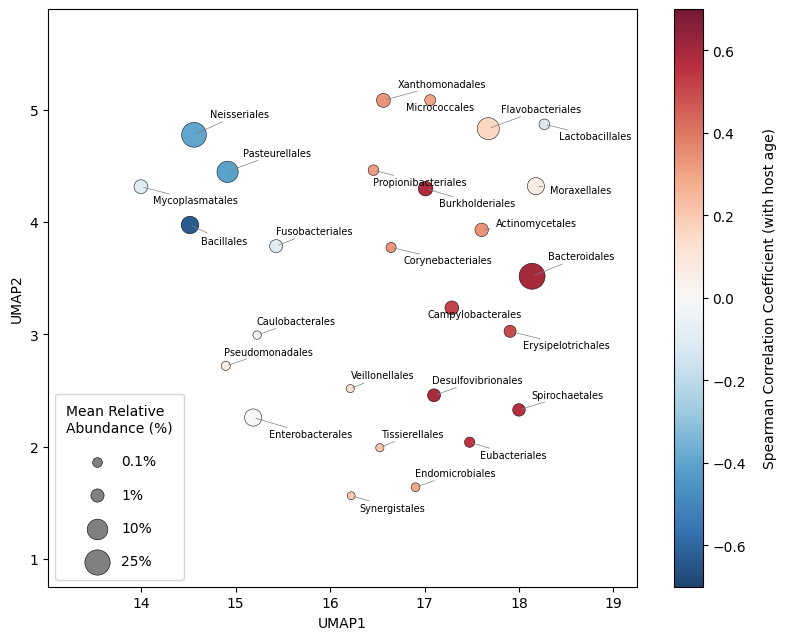

In [8]:
# Plot UMAP: Corr_Dist
fig, ax = plt.subplots(figsize=(9.5,7.5))

dot_sizes = scale_sizes(
    umap_df["order_mean_abundance"].values,
    min_s = 30,
    max_s = 360
)
# Legend sizes for the scatter plot

# 0.1%, 1%, 10%, 25%
leg_abund = [0.001, 0.01, 0.1, 0.25] 
leg_label = ["0.1%", "1%", "10%", "25%"]

# Create the dots to be shown on the legend, according to the dot sizes in leg_abund
leg_dots_sizes = scale_sizes(
    leg_abund,
    min_s = 30,
    max_s = 360)

# Reference dots sizes appropriately for legend

# For each size in the key (size is a placeholder variable for the size in leg_dots_sizes) -> draw a dot
# It is tech a scatter plot with no data, just to show the size of the dots in the legend -> all 4 dots into a list 

# Invisible scatter plots for legend dots
leg_dots_handles = [
    ax.scatter([], [], s=size, edgecolors='black', linewidth=0.4, facecolor="gray") for size in leg_dots_sizes]# [] = 2 empty x and y values

p = ax.scatter(
    umap_df["UMAP 1"],
    umap_df["UMAP 2"],
    cmap="RdBu_r",
    c=umap_df["spearman_r"],
    s= dot_sizes,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.4,
    # The min and max values of spearman correlation aren't 0 and 1 -> manually code
    vmax = 0.7,
    vmin = -0.7,
)

# Cleaned order names
order_names_cleaned = [clean_label(order) for order in umap_df.index]

# Label text
order_text = [ # Collect all the text labels for the orders in a list
    ax.text(x, y, order_name, fontsize=7) # Write the order name at the x and y coordinates of the UMAP embedding, size 8 font
    for x, y, order_name in zip( # Dot by dot: Walk through the 3 lists in parallel; UMAP 1, UMAP 2, and order names cleaned and gives it
        umap_df["UMAP 1"],
        umap_df["UMAP 2"],
        order_names_cleaned
    )
]

ax.margins(0.23) # Add margins to the plot so that the text doesn't get cut off

# Label dots

adjust_text(
    order_text,
    objects=p,
    expand=(1.5, 1.6),
    force_static=(0.8, 1.3),
    force_text=(0.5, 0.7),
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, shrinkA=5),
)
# expand: invisible padding around each order name (horizontal, vertical)
# force_static: dots push order names
# force_text: order names push each other apart

# Show the colorbar for pearson correlation
colorbar = plt.colorbar(p)
colorbar.set_label("Spearman Correlation Coefficient (with host age)",
                    labelpad = 12
                   )

ax.set_xlabel("UMAP1", fontsize=10)
ax.set_ylabel("UMAP2", fontsize=10)
ax.legend(
    leg_dots_handles,
    leg_label, 
     title="Mean Relative\nAbundance (%)",
     handletextpad=0.75, # Add space between dot and text
     borderpad=0.8, # Add space between legend border and text
     labelspacing=1.4, # Add space between legend entries,
     loc="lower left"
)
# ax.set_title(
    # "Bacterial Order UMAP\n(log10(Order Level Relative Abundances)) - Correlation Distance",
    # fontsize=12
# )

plt.show()

fig.savefig("bacterial_order_umap.pdf", bbox_inches="tight")

In [9]:
print(umap_df.columns)
umap_df["order_mean_abundance"].describe()

print(umap_df.index[:3].tolist())

# Check order names cleaning worked
print(order_names_cleaned[:5])
print(len(order_names_cleaned))

Index(['UMAP 1', 'UMAP 2', 'order_mean_abundance', 'spearman_r', 'p'], dtype='str')
['k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales', 'k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Corynebacteriales', 'k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Micrococcales']
['Actinomycetales', 'Corynebacteriales', 'Micrococcales', 'Propionibacteriales', 'Bacteroidales']
27
